# ILN05 - Modelos clásicos: TF-IDF + Logistic Regression

En este notebook se desarrollan los modelos clásicos para la tarea *Movie Genre Identification Task*.

El objetivo es construir un sistema multi-etiqueta capaz de predecir uno o varios géneros de una película a partir de su título y su descripción. Se parte de un baseline sencillo con `CountVectorizer` y `MultinomialNB`, y después se prueban representaciones TF-IDF, modelos lineales, n-gramas de palabras/caracteres y ajuste de umbrales por clase.

In [1]:
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    accuracy_score,
    hamming_loss,
    precision_recall_fscore_support,
    classification_report,
    f1_score
)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion

## 1. Carga de datos

Se descomprime el dataset y se cargan los ficheros de entrenamiento y test. El conjunto de entrenamiento contiene las etiquetas reales, mientras que el conjunto de test se utiliza únicamente para generar el fichero de predicciones.

In [2]:
from pathlib import Path

train_path = Path("dataset_train.csv")
test_path = Path("dataset_test.csv")

if not train_path.exists() or not test_path.exists():
    with zipfile.ZipFile("Dataset-Movies.zip", "r") as zip_ref:
        zip_ref.extractall(".")
    print("Dataset descomprimido.")
else:
    print("Los CSV ya existen. No se descomprime de nuevo.")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

display(train_df.head())
display(test_df.head())

Dataset descomprimido.
Train: (8475, 3)
Test: (942, 2)


,movie_name,genre,description
0,Silent Hill,"Horror, Mystery","Rose, a desperate mother takes her adopted dau..."
1,Breaking the Waves,"Drama, Romance","In a small and conservative Scottish village, ..."
2,Wind Chill,"Drama, Horror, Thriller",Two college students share a ride home for the...
3,Godmothered,"Family, Fantasy, Comedy",A young and unskilled fairy godmother that ven...
4,Donkey Skin,"Fantasy, Comedy, Music, Romance",A fairy godmother helps a princess disguise he...


,movie_name,description
0,Opposites Attract,"She's a divorce lawyer, single mother and perp..."
1,A Turtle's Tale: Sammy's Adventures,A sea turtle who was hatched in 1959 spends th...
2,My Stepmother Is an Alien,Trying to rescue her home planet from destruct...
3,You've Got Mail,"Book superstore magnate, Joe Fox and independe..."
4,The Thing,"In the winter of 1982, a twelve-man research t..."


In [3]:
print("Columnas de train:")
print(train_df.columns.tolist())

print("\nValores nulos en train:")
display(train_df.isna().sum())

print("\nValores nulos en test:")
display(test_df.isna().sum())

Columnas de train:
['movie_name', 'genre', 'description']

Valores nulos en train:


,0
movie_name,0
genre,0
description,0



Valores nulos en test:


,0
movie_name,0
description,0


In [4]:
train_df["genre_list"] = train_df["genre"].apply(
    lambda x: [g.strip() for g in x.split(",")]
)

genre_counter = Counter()

for genre_list in train_df["genre_list"]:
    genre_counter.update(genre_list)

genre_counts = pd.Series(genre_counter).sort_values(ascending=False)

display(genre_counts)

print("Número de géneros:", len(genre_counts))
print("Media de géneros por película:", train_df["genre_list"].apply(len).mean())
print("Máximo de géneros en una película:", train_df["genre_list"].apply(len).max())
print("Mínimo de géneros en una película:", train_df["genre_list"].apply(len).min())

,0
Drama,3957
Comedy,3046
Thriller,2289
Action,1974
Romance,1483
Adventure,1429
Crime,1362
Horror,1159
Science Fiction,1004
Family,969


Número de géneros: 18
Media de géneros por película: 2.6510914454277286
Máximo de géneros en una película: 9
Mínimo de géneros en una película: 1


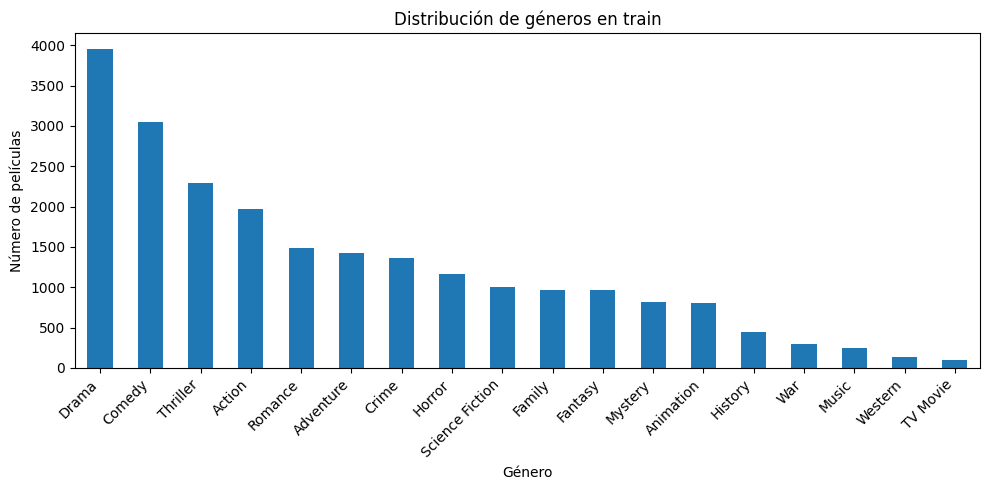

In [5]:
plt.figure(figsize=(10, 5))
genre_counts.plot(kind="bar")
plt.title("Distribución de géneros en train")
plt.ylabel("Número de películas")
plt.xlabel("Género")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,count
genre_list,
1,1187
2,2610
3,3144
4,1137
5,324
6,55
7,14
8,3
9,1


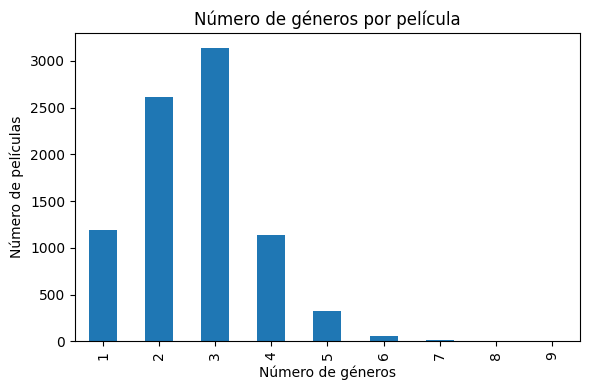

In [6]:
num_genres_per_movie = train_df["genre_list"].apply(len)

display(num_genres_per_movie.value_counts().sort_index())

plt.figure(figsize=(6, 4))
num_genres_per_movie.value_counts().sort_index().plot(kind="bar")
plt.title("Número de géneros por película")
plt.xlabel("Número de géneros")
plt.ylabel("Número de películas")
plt.tight_layout()
plt.show()

## 3. Preparación de etiquetas y texto

Las etiquetas se transforman con `MultiLabelBinarizer`, generando una matriz binaria con una columna por género. Para el texto de entrada se combina el título y la descripción de cada película.

In [7]:
mlb = MultiLabelBinarizer()

Y = mlb.fit_transform(train_df["genre_list"])
genres = list(mlb.classes_)

print("Géneros:")
print(genres)

print("\nShape de Y:", Y.shape)

Géneros:
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

Shape de Y: (8475, 18)


In [8]:
train_df["text"] = (
    "Title: " + train_df["movie_name"].fillna("") +
    ". Plot: " + train_df["description"].fillna("")
)

test_df["text"] = (
    "Title: " + test_df["movie_name"].fillna("") +
    ". Plot: " + test_df["description"].fillna("")
)

display(train_df[["movie_name", "genre", "text"]].head())

,movie_name,genre,text
0,Silent Hill,"Horror, Mystery","Title: Silent Hill. Plot: Rose, a desperate mo..."
1,Breaking the Waves,"Drama, Romance",Title: Breaking the Waves. Plot: In a small an...
2,Wind Chill,"Drama, Horror, Thriller",Title: Wind Chill. Plot: Two college students ...
3,Godmothered,"Family, Fantasy, Comedy",Title: Godmothered. Plot: A young and unskille...
4,Donkey Skin,"Fantasy, Comedy, Music, Romance",Title: Donkey Skin. Plot: A fairy godmother he...


## 4. División entrenamiento-validación

Se reserva un 20% del conjunto de entrenamiento como validación interna. Esta partición se utiliza para comparar modelos y ajustar umbrales por clase.

In [9]:
X = train_df["text"]
X_test = test_df["text"]

X_train, X_dev, y_train, y_dev = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_dev:", X_dev.shape)
print("y_train:", y_train.shape)
print("y_dev:", y_dev.shape)

X_train: (6780,)
X_dev: (1695,)
y_train: (6780, 18)
y_dev: (1695, 18)


In [10]:
comparison = pd.DataFrame({
    "train_count": pd.Series(y_train.sum(axis=0), index=genres),
    "dev_count": pd.Series(y_dev.sum(axis=0), index=genres),
    "total_count": pd.Series(Y.sum(axis=0), index=genres)
}).sort_values("total_count", ascending=False)

display(comparison)

,train_count,dev_count,total_count
Drama,3168,789,3957
Comedy,2421,625,3046
Thriller,1818,471,2289
Action,1563,411,1974
Romance,1215,268,1483
Adventure,1151,278,1429
Crime,1089,273,1362
Horror,928,231,1159
Science Fiction,791,213,1004
Family,791,178,969


## 5. Funciones auxiliares

Se definen las métricas de evaluación y funciones para ajustar umbrales por clase. Además de las métricas oficiales, se calcula el número medio de etiquetas predichas para interpretar mejor el comportamiento de cada modelo.

In [11]:
def compute_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    hl = hamming_loss(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_macro": f1,
        "hamming_loss": hl,
        "avg_labels_pred": y_pred.sum(axis=1).mean(),
        "avg_labels_true": y_true.sum(axis=1).mean()
    }


def find_best_thresholds(y_true, y_scores, thresholds=np.arange(0.05, 0.96, 0.01)):
    best_thresholds = []
    best_f1s = []

    for j in range(y_true.shape[1]):
        best_t = 0.5
        best_f1 = 0.0

        for t in thresholds:
            y_pred_j = (y_scores[:, j] >= t).astype(int)
            f1 = f1_score(y_true[:, j], y_pred_j, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        best_thresholds.append(best_t)
        best_f1s.append(best_f1)

    return np.array(best_thresholds), np.array(best_f1s)


def evaluate_with_thresholds(model, X_dev, y_dev):
    y_scores = model.predict_proba(X_dev)

    thresholds, class_f1s = find_best_thresholds(y_dev, y_scores)

    y_pred = (y_scores >= thresholds).astype(int)
    metrics = compute_metrics(y_dev, y_pred)

    return metrics, thresholds, class_f1s, y_pred, y_scores

In [12]:
def build_word_char_logreg(C=2.0, word_ngram=(1, 3)):
    return Pipeline([
        ("features", FeatureUnion([
            ("word_tfidf", TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="word",
                ngram_range=word_ngram,
                min_df=2,
                max_df=0.9,
                max_features=50000,
                sublinear_tf=True,
                stop_words="english"
            )),
            ("char_tfidf", TfidfVectorizer(
                lowercase=True,
                strip_accents="unicode",
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2,
                max_features=50000,
                sublinear_tf=True
            ))
        ])),
        ("classifier", OneVsRestClassifier(
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                C=C,
                solver="liblinear"
            )
        ))
    ])

## 6. Experimentos con modelos clásicos

Se prueban varios modelos clásicos sobre la misma partición de validación: un baseline con Naive Bayes, modelos lineales con TF-IDF y la configuración final con n-gramas de palabras y caracteres.

In [13]:
results = []

baseline_nb = Pipeline([
    ("vectorizer", CountVectorizer(
        analyzer="word",
        max_features=5000,
        lowercase=True,
        stop_words="english"
    )),
    ("classifier", OneVsRestClassifier(MultinomialNB()))
])

baseline_nb.fit(X_train, y_train)
y_pred_nb = baseline_nb.predict(X_dev)

metrics = compute_metrics(y_dev, y_pred_nb)
metrics["model"] = "CountVectorizer + MultinomialNB"
results.append(metrics)

display(metrics)

{'accuracy': 0.11563421828908554,
 'precision': 0.515991854490849,
 'recall': 0.5249114971298346,
 'f1_macro': 0.5112582483601675,
 'hamming_loss': 0.11717469682071452,
 'avg_labels_pred': np.float64(2.8507374631268436),
 'avg_labels_true': np.float64(2.6601769911504425),
 'model': 'CountVectorizer + MultinomialNB'}

In [14]:
tfidf_logreg = Pipeline([
    ("vectorizer", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        max_features=50000,
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", OneVsRestClassifier(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=1.0,
            solver="liblinear"
        )
    ))
])

tfidf_logreg.fit(X_train, y_train)
y_pred_lr = tfidf_logreg.predict(X_dev)

metrics = compute_metrics(y_dev, y_pred_lr)
metrics["model"] = "TF-IDF word + LogisticRegression"
results.append(metrics)

display(metrics)

{'accuracy': 0.128023598820059,
 'precision': 0.5674489269292575,
 'recall': 0.5729639202264586,
 'f1_macro': 0.5615820706089102,
 'hamming_loss': 0.11261881350376926,
 'avg_labels_pred': np.float64(2.882005899705015),
 'avg_labels_true': np.float64(2.6601769911504425),
 'model': 'TF-IDF word + LogisticRegression'}

In [15]:
tfidf_svc = Pipeline([
    ("vectorizer", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        max_features=50000,
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", OneVsRestClassifier(
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=42
        )
    ))
])

tfidf_svc.fit(X_train, y_train)
y_pred_svc = tfidf_svc.predict(X_dev)

metrics = compute_metrics(y_dev, y_pred_svc)
metrics["model"] = "TF-IDF word + LinearSVC"
results.append(metrics)

display(metrics)

{'accuracy': 0.1486725663716814,
 'precision': 0.6635945112908401,
 'recall': 0.47461986130258477,
 'f1_macro': 0.5248628383025379,
 'hamming_loss': 0.10904621435594887,
 'avg_labels_pred': np.float64(2.392920353982301),
 'avg_labels_true': np.float64(2.6601769911504425),
 'model': 'TF-IDF word + LinearSVC'}

In [16]:
classic_model_dev = build_word_char_logreg(C=2.0, word_ngram=(1, 3))
classic_model_dev.fit(X_train, y_train)

metrics_classic, best_thresholds, best_f1s, y_pred_classic, y_scores_classic = evaluate_with_thresholds(
    classic_model_dev,
    X_dev,
    y_dev
)

metrics_classic["model"] = "TF-IDF word+char + LogReg + thresholds"
results.append(metrics_classic)

display(metrics_classic)

{'accuracy': 0.128023598820059,
 'precision': 0.5625720319882156,
 'recall': 0.6417971915895238,
 'f1_macro': 0.5942411783728392,
 'hamming_loss': 0.1115372009177319,
 'avg_labels_pred': np.float64(3.133923303834808),
 'avg_labels_true': np.float64(2.6601769911504425),
 'model': 'TF-IDF word+char + LogReg + thresholds'}

In [17]:
results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
display(results_df)

,accuracy,precision,recall,f1_macro,hamming_loss,avg_labels_pred,avg_labels_true,model
3,0.128024,0.562572,0.641797,0.594241,0.111537,3.133923,2.660177,TF-IDF word+char + LogReg + thresholds
1,0.128024,0.567449,0.572964,0.561582,0.112619,2.882006,2.660177,TF-IDF word + LogisticRegression
2,0.148673,0.663595,0.474620,0.524863,0.109046,2.392920,2.660177,TF-IDF word + LinearSVC
0,0.115634,0.515992,0.524911,0.511258,0.117175,2.850737,2.660177,CountVectorizer + MultinomialNB


In [18]:
thresholds_df = pd.DataFrame({
    "genre": genres,
    "threshold": best_thresholds,
    "dev_f1_class": best_f1s,
    "support_dev": y_dev.sum(axis=0)
}).sort_values("genre")

display(thresholds_df)

,genre,threshold,dev_f1_class,support_dev
0,Action,0.41,0.732424,411
1,Adventure,0.58,0.589147,278
2,Animation,0.45,0.632219,172
3,Comedy,0.42,0.702970,625
4,Crime,0.52,0.633517,273
5,Drama,0.38,0.724781,789
6,Family,0.43,0.637975,178
7,Fantasy,0.44,0.506329,189
8,History,0.34,0.422414,90
9,Horror,0.43,0.664107,231


In [19]:
print(classification_report(
    y_dev,
    y_pred_classic,
    target_names=genres,
    zero_division=0
))

                 precision    recall  f1-score   support

         Action       0.64      0.85      0.73       411
      Adventure       0.64      0.55      0.59       278
      Animation       0.66      0.60      0.63       172
         Comedy       0.63      0.80      0.70       625
          Crime       0.64      0.63      0.63       273
          Drama       0.64      0.84      0.72       789
         Family       0.58      0.71      0.64       178
        Fantasy       0.49      0.53      0.51       189
        History       0.35      0.54      0.42        90
         Horror       0.60      0.75      0.66       231
          Music       0.60      0.55      0.57        53
        Mystery       0.45      0.55      0.49       163
        Romance       0.54      0.61      0.58       268
Science Fiction       0.74      0.63      0.68       213
       TV Movie       0.16      0.35      0.22        17
       Thriller       0.61      0.73      0.67       471
            War       0.64    

## 7. Entrenamiento final y generación del envío

Una vez seleccionada la configuración final, se entrena el modelo clásico con todo el conjunto de entrenamiento etiquetado. Para predecir el test se reutilizan los umbrales aprendidos en la partición de validación.

In [20]:
final_classic_model = build_word_char_logreg(C=2.0, word_ngram=(1, 3))
final_classic_model.fit(train_df["text"], Y)

test_scores = final_classic_model.predict_proba(test_df["text"])
test_pred_bin = (test_scores >= best_thresholds).astype(int)

# Si alguna película queda sin género, se asigna el género con mayor score.
for i in range(test_pred_bin.shape[0]):
    if test_pred_bin[i].sum() == 0:
        test_pred_bin[i, test_scores[i].argmax()] = 1

test_pred_labels = mlb.inverse_transform(test_pred_bin)

submission_df = pd.DataFrame({
    "movie_name": test_df["movie_name"],
    "description": test_df["description"],
    "genre": [", ".join(labels) for labels in test_pred_labels]
})

display(submission_df.head())
print(submission_df.shape)

,movie_name,description,genre
0,Opposites Attract,"She's a divorce lawyer, single mother and perp...","Comedy, Drama, Romance"
1,A Turtle's Tale: Sammy's Adventures,A sea turtle who was hatched in 1959 spends th...,"Adventure, Animation, Comedy, Drama, Family"
2,My Stepmother Is an Alien,Trying to rescue her home planet from destruct...,"Drama, Family, Romance, Science Fiction, TV Movie"
3,You've Got Mail,"Book superstore magnate, Joe Fox and independe...","Comedy, Family, Romance"
4,The Thing,"In the winter of 1982, a twelve-man research t...","Action, Horror, Science Fiction"


(942, 3)


In [21]:
submission_df.to_csv("dataset_test_preds.csv", index=False)

with zipfile.ZipFile("ILN05-LogReg-TFIDF-CharNgrams.zip", "w") as zipf:
    zipf.write("dataset_test_preds.csv")

In [24]:
check_df = pd.read_csv("dataset_test_preds.csv")

print(check_df.shape)
print(check_df.columns.tolist())
print("Nulos en genre:", check_df["genre"].isna().sum())
print("Géneros vacíos:", (check_df["genre"].str.len() == 0).sum())

with zipfile.ZipFile("ILN05-LogReg-TFIDF-CharNgrams.zip", "r") as zipf:
    print(zipf.namelist())

(942, 3)
['movie_name', 'description', 'genre']
Nulos en genre: 0
Géneros vacíos: 0
['dataset_test_preds.csv']
